# Phase 5 — Dashboard Preview

Static notebook version of the Streamlit dashboard (`app/dashboard.py`).

**Sections:**
1. Network KPI monitor (RSRP / SINR over time)
2. Handover event timeline
3. Predicted risk timeline (Random Forest)
4. UE mobility tracks
5. Model summary card

> Launch the live dashboard with:
> ```bash
> streamlit run app/dashboard.py
> ```

In [1]:
import sys, json
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
from pathlib import Path

from src.models import load_splits, xy

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

MODELS_DIR = Path('../models')
ROOT       = Path('..')

raw  = pd.read_csv(ROOT / 'data' / 'raw' / 'dataset.csv')
train, val, test, feat_cols, meta = load_splits()

rf = joblib.load(MODELS_DIR / 'random_forest.pkl')
rf_probs = rf.predict_proba(test[feat_cols].fillna(0).values)[:, 1]
test = test.copy()
test['risk'] = rf_probs

# Focus on a few UEs in a 300-second window for clarity
FOCUS_UES  = [8, 9, 10, 11]   # vehicle UEs — more interesting HO behaviour
T_START, T_END = 200, 500

view = raw[raw['ue_id'].isin(FOCUS_UES) & raw['timestamp'].between(T_START, T_END)]
print(f'View: {len(view)} rows | UEs: {FOCUS_UES} | t=[{T_START},{T_END}]')

View: 1204 rows | UEs: [8, 9, 10, 11] | t=[200,500]


## 1. Radio KPI Monitor

/var/folders/10/471w2rks2_g1vsz0bq3bm2_00000gn/T/ipykernel_49001/3674922705.py:28: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/Users/apple/Desktop/Intelligent_Handover_Prediction_in_LTE_Networks_using_ML/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


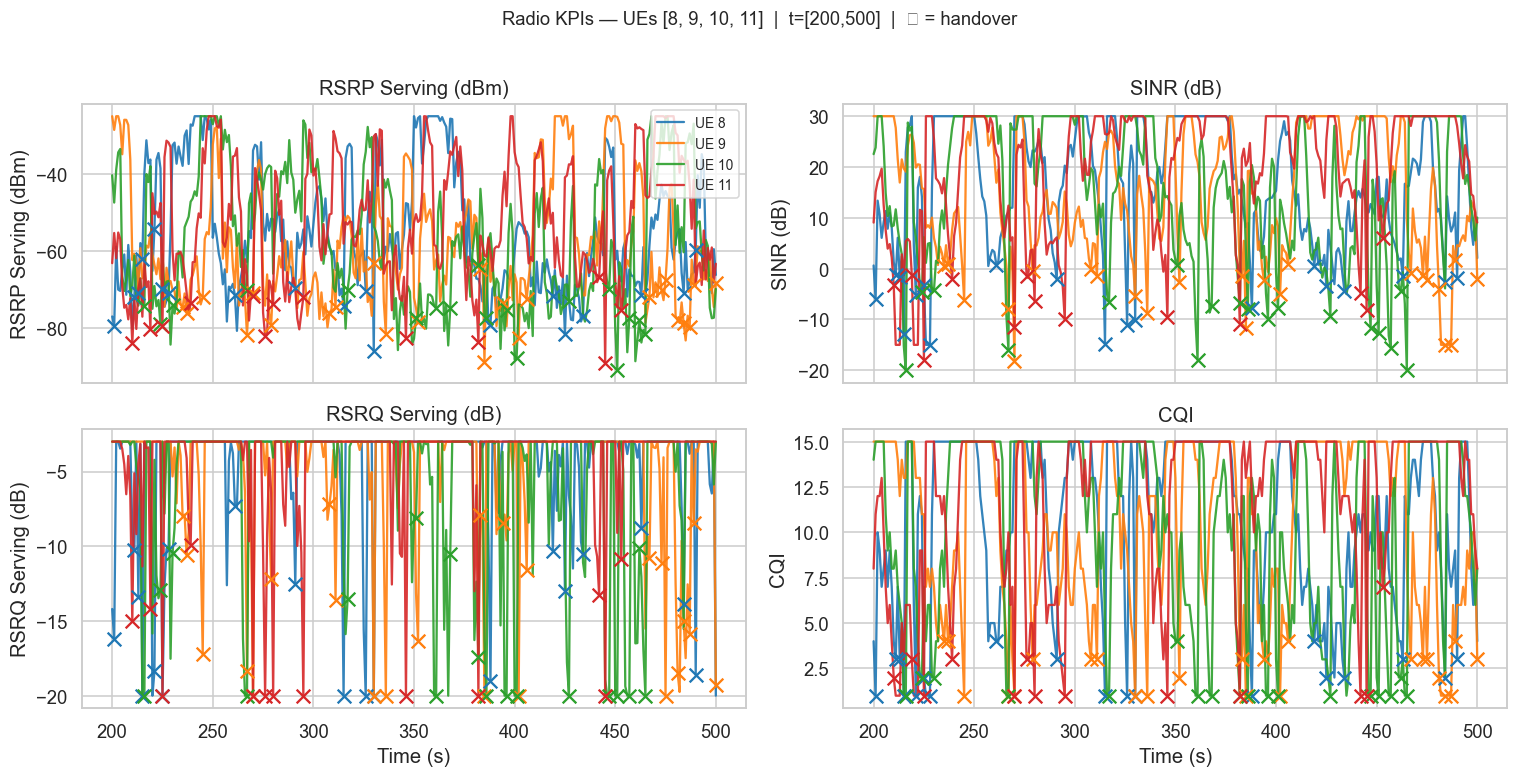

In [2]:
COLORS = plt.cm.tab10.colors

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
kpis = [
    ('rsrp_serving', 'RSRP Serving (dBm)'),
    ('sinr',         'SINR (dB)'),
    ('rsrq_serving', 'RSRQ Serving (dB)'),
    ('cqi',          'CQI'),
]

for ax, (col, label) in zip(axes.flat, kpis):
    for i, ue_id in enumerate(FOCUS_UES):
        ue = view[view['ue_id'] == ue_id]
        ax.plot(ue['timestamp'], ue[col], lw=1.5, alpha=0.9,
                color=COLORS[i], label=f'UE {ue_id}')
        # Mark handover events
        ho = ue[ue['handover_event'] == 1]
        ax.scatter(ho['timestamp'], ho[col], color=COLORS[i],
                   marker='x', s=80, zorder=5)
    ax.set_ylabel(label); ax.set_title(label)

axes.flat[0].legend(fontsize=9, loc='upper right')
for ax in axes[1]:
    ax.set_xlabel('Time (s)')

plt.suptitle(f'Radio KPIs — UEs {FOCUS_UES}  |  t=[{T_START},{T_END}]  |  ✗ = handover',
             fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

## 2. Handover Event Timeline

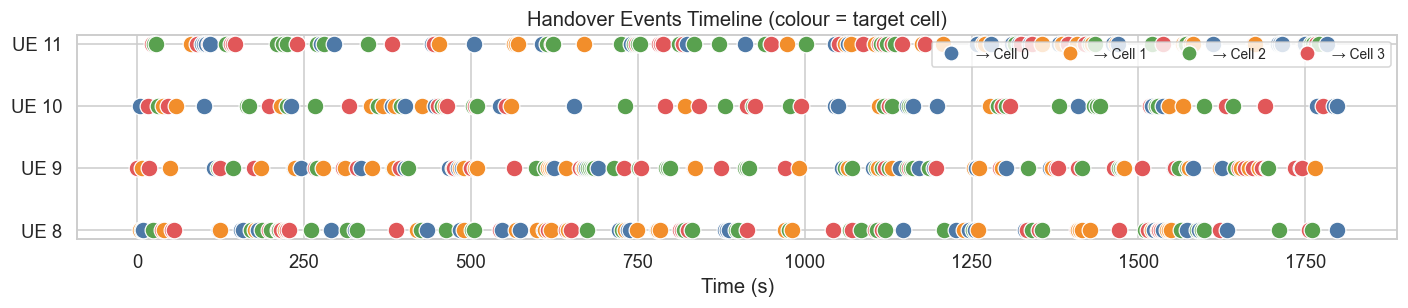

In [3]:
ho_all = raw[(raw['ue_id'].isin(FOCUS_UES)) & (raw['handover_event'] == 1)]

fig, ax = plt.subplots(figsize=(13, 3))

cell_colors = {0: '#4e79a7', 1: '#f28e2b', 2: '#59a14f', 3: '#e15759'}
for _, row in ho_all.iterrows():
    ax.scatter(row['timestamp'], row['ue_id'],
               color=cell_colors.get(int(row['target_cell_id']), 'gray'),
               s=120, zorder=3, edgecolors='white', lw=0.8)

from matplotlib.lines import Line2D
legend_handles = [Line2D([0],[0], marker='o', color='w',
                          markerfacecolor=c, markersize=10, label=f'→ Cell {k}')
                  for k, c in cell_colors.items()]
ax.legend(handles=legend_handles, fontsize=9, loc='upper right', ncol=4)

ax.set_yticks(FOCUS_UES)
ax.set_yticklabels([f'UE {u}' for u in FOCUS_UES])
ax.set_xlabel('Time (s)')
ax.set_title('Handover Events Timeline (colour = target cell)')
plt.tight_layout(); plt.show()

## 3. Predicted Handover Risk (Random Forest)

The model outputs a probability for each UE at each timestep.  
Risk > 0.5 → predicted `handover_soon = 1`.

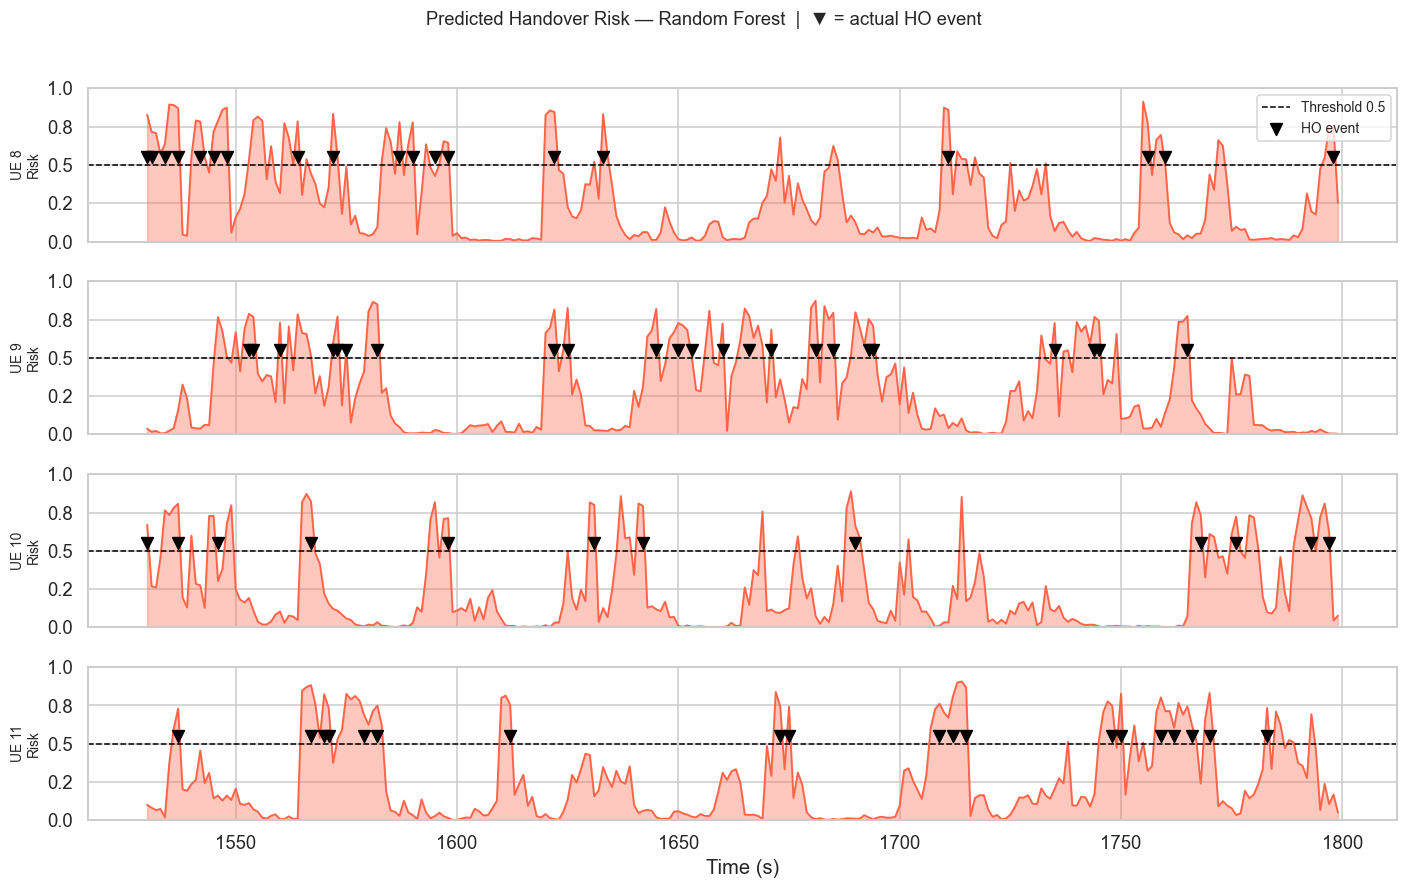

In [4]:
fig, axes = plt.subplots(len(FOCUS_UES), 1, figsize=(13, 8), sharex=True)
THRESHOLD = 0.5

for ax, ue_id in zip(axes, FOCUS_UES):
    ue_test = test[test['ue_id'] == ue_id].sort_values('timestamp')
    if len(ue_test) == 0:
        ax.set_ylabel(f'UE {ue_id}', fontsize=9); continue

    ax.fill_between(ue_test['timestamp'], 0, ue_test['risk'],
                    alpha=0.35, color='tomato')
    ax.plot(ue_test['timestamp'], ue_test['risk'], lw=1.2, color='tomato')
    ax.axhline(THRESHOLD, ls='--', color='black', lw=1, label='Threshold 0.5')

    # Mark actual handover events
    ho_ue = ue_test[ue_test['handover_event'] == 1]
    ax.scatter(ho_ue['timestamp'], [THRESHOLD + 0.05] * len(ho_ue),
               marker='v', color='black', s=60, zorder=5, label='HO event')

    ax.set_ylim(0, 1)
    ax.set_ylabel(f'UE {ue_id}\nRisk', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}'))

axes[0].legend(fontsize=9, loc='upper right')
axes[-1].set_xlabel('Time (s)')
plt.suptitle('Predicted Handover Risk — Random Forest  |  ▼ = actual HO event',
             fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

## 4. Risk Heatmap — All UEs

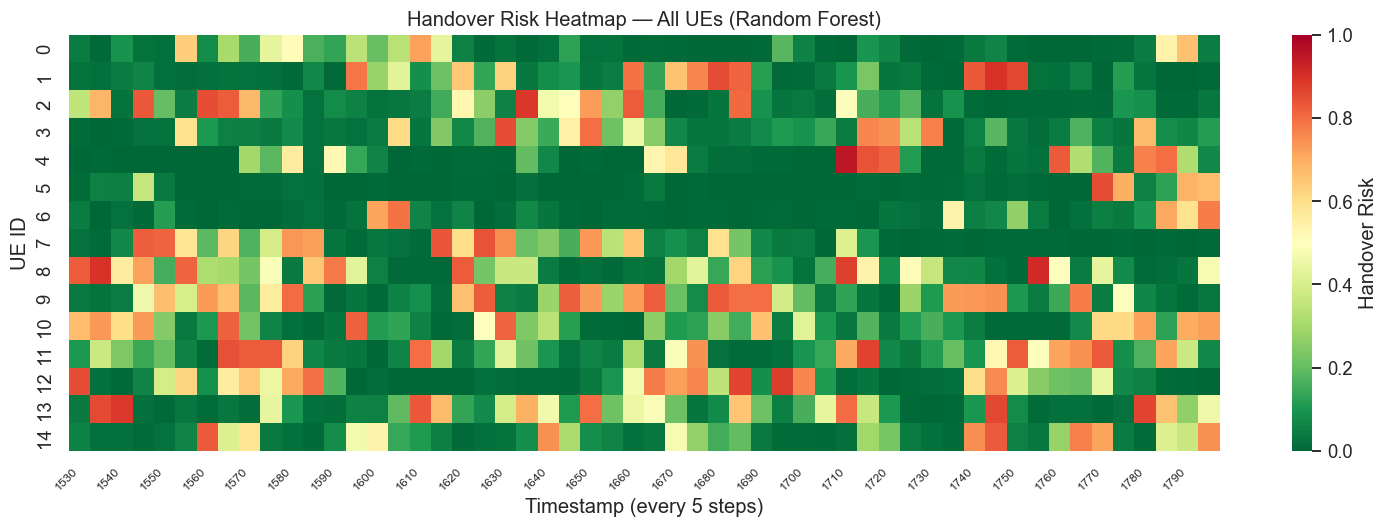

In [5]:
# Pivot: rows = UE, columns = timestamp (sampled every 5 steps)
pivot = test.pivot_table(index='ue_id', columns='timestamp', values='risk', aggfunc='mean')
pivot_sampled = pivot.iloc[:, ::5]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_sampled, cmap='RdYlGn_r', vmin=0, vmax=1,
            ax=ax, cbar_kws={'label': 'Handover Risk'},
            linewidths=0)
ax.set_xlabel('Timestamp (every 5 steps)'); ax.set_ylabel('UE ID')
ax.set_title('Handover Risk Heatmap — All UEs (Random Forest)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.tight_layout(); plt.show()

## 5. UE Mobility Tracks with Cell Colouring

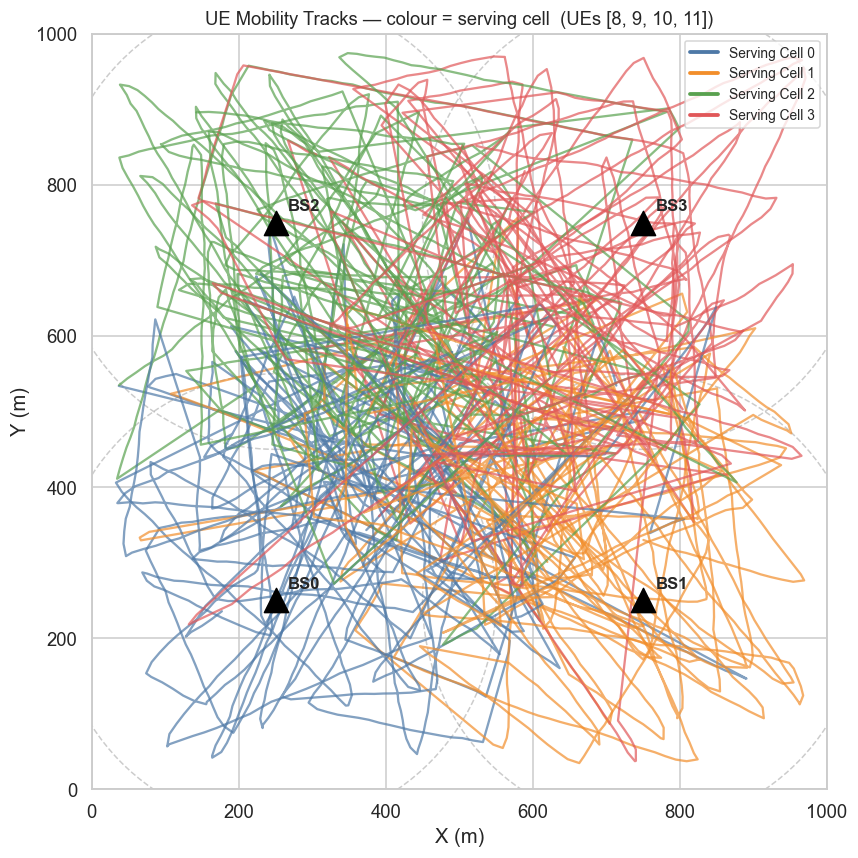

In [6]:
BS_POSITIONS = {0: (250,250), 1: (750,250), 2: (250,750), 3: (750,750)}
cell_cmap = {0: '#4e79a7', 1: '#f28e2b', 2: '#59a14f', 3: '#e15759'}

fig, ax = plt.subplots(figsize=(8, 8))

for ue_id in FOCUS_UES:
    ue_data = raw[raw['ue_id'] == ue_id].sort_values('timestamp')
    for cell_id, grp in ue_data.groupby('serving_cell_id'):
        ax.plot(grp['pos_x'], grp['pos_y'],
                color=cell_cmap.get(cell_id, 'gray'),
                lw=1.5, alpha=0.7)

# Base stations
for bs_id, (bx, by) in BS_POSITIONS.items():
    ax.scatter(bx, by, s=250, marker='^', color='black', zorder=6)
    ax.annotate(f'BS{bs_id}', (bx, by), textcoords='offset points',
                xytext=(8, 8), fontsize=11, fontweight='bold')
    circle = plt.Circle((bx, by), 300, fill=False,
                         linestyle='--', lw=1, color='gray', alpha=0.4)
    ax.add_patch(circle)

from matplotlib.lines import Line2D
legend_handles = [Line2D([0],[0], color=c, lw=2.5, label=f'Serving Cell {k}')
                  for k, c in cell_cmap.items()]
ax.legend(handles=legend_handles, fontsize=9, loc='upper right')

ax.set_xlim(0, 1000); ax.set_ylim(0, 1000)
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_title(f'UE Mobility Tracks — colour = serving cell  (UEs {FOCUS_UES})', fontsize=12)
plt.tight_layout(); plt.show()

## 6. Model Summary Card

In [7]:
report_path = Path('../reports/evaluation.txt')
if report_path.exists():
    lines = report_path.read_text().splitlines()
    # Print the comparison summary section
    in_summary = False
    for line in lines:
        if 'COMPARISON SUMMARY' in line:
            in_summary = True
        if in_summary:
            print(line)
else:
    print('Run run_pipeline.py --phase 4 first to generate the report.')

  COMPARISON SUMMARY

  Best F1      : Random Forest  (0.5206)
  Best ROC-AUC : Random Forest  (0.9088)

  ANALYSIS:

  • Logistic Regression is a fast linear baseline. It struggles
    with the non-linear RSRP/SINR boundary dynamics but provides
    a useful lower bound and interpretable coefficients.

  • Random Forest captures feature interactions (RSRP gap,
    rolling trends, delta features) that the linear model misses.
    Ensemble bagging reduces variance on the rare positive class.
    Feature importances expose which KPIs drive the prediction.

  • LSTM models the temporal evolution of radio metrics directly,
    allowing it to detect degrading RSRP trends before the A3
    event fires — this makes it the most suitable model for
    proactive handover prediction in production.

  RECOMMENDATION FOR DEPLOYMENT:
    Use Random Forest for low-latency inference with explainability;
    LSTM when historical context (last 10 s) is available.


/var/folders/10/471w2rks2_g1vsz0bq3bm2_00000gn/T/ipykernel_49001/2290452626.py:59: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/Users/apple/Desktop/Intelligent_Handover_Prediction_in_LTE_Networks_using_ML/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


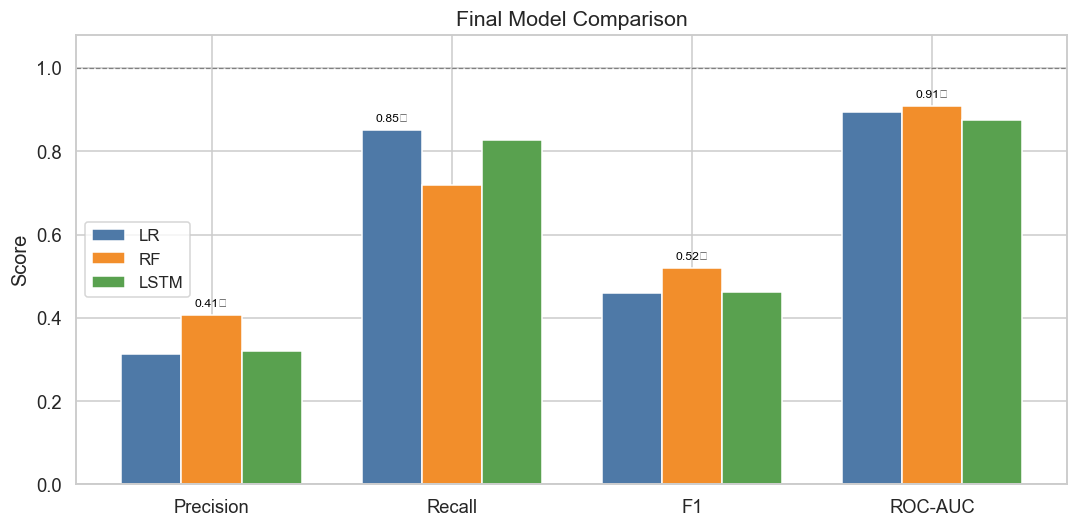

In [8]:
# Final summary radar / bar comparison
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import joblib, torch
from src.models import LSTMClassifier, SequenceDataset, SEQ_LEN

_, y_test = xy(test, feat_cols)

lr  = joblib.load(MODELS_DIR / 'logistic_regression.pkl')
lr_p = lr.predict_proba(test[feat_cols].fillna(0).values)[:, 1]
rf_p = rf_probs  # already computed

lstm_m = LSTMClassifier(input_size=len(feat_cols))
lstm_m.load_state_dict(torch.load(MODELS_DIR / 'lstm.pt', map_location='cpu'))
lstm_m.eval()
ds = SequenceDataset(test, feat_cols, seq_len=SEQ_LEN)
loader = torch.utils.data.DataLoader(ds, batch_size=512, shuffle=False)
lstm_p, lstm_l = [], []
with torch.no_grad():
    for xb, yb in loader:
        lstm_p.extend(torch.sigmoid(lstm_m(xb)).numpy())
        lstm_l.extend(yb.numpy().astype(int))
lstm_p = np.array(lstm_p); lstm_l = np.array(lstm_l)

summary = {}
for name, p, y in [('LR', lr_p, y_test), ('RF', rf_p, y_test), ('LSTM', lstm_p, lstm_l)]:
    pred = (p >= 0.5).astype(int)
    summary[name] = {
        'Precision': precision_score(y, pred, zero_division=0),
        'Recall':    recall_score(y, pred, zero_division=0),
        'F1':        f1_score(y, pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y, p),
    }

metrics = ['Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#4e79a7', '#f28e2b', '#59a14f']
for i, (name, vals) in enumerate(summary.items()):
    ax.bar(x + i * width, [vals[m] for m in metrics],
           width, label=name, color=colors_bar[i], edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.set_title('Final Model Comparison', fontsize=14)
ax.legend(fontsize=11)
ax.axhline(1.0, ls='--', color='gray', lw=0.8)

# Annotate best bar per metric
for j, m in enumerate(metrics):
    best_val = max(summary[n][m] for n in summary)
    best_name = max(summary, key=lambda n: summary[n][m])
    ax.annotate(f'{best_val:.2f}★',
                xy=(j + list(summary.keys()).index(best_name) * width, best_val + 0.02),
                ha='center', fontsize=8, color='black')

plt.tight_layout(); plt.show()

## Launch the Live Dashboard

```bash
cd lte_handover_prediction
streamlit run app/dashboard.py
```

The dashboard provides:
- **Interactive UE/time filters** (sidebar)
- **Live KPI charts** with handover event markers
- **Risk heatmap** + **gauge** (per selected model)
- **Model comparison table** (from evaluation report)
- **UE mobility map** with BS positions